<a href="https://colab.research.google.com/github/amanvashisth/Deep-Learning/blob/master/Improve%20Neural%20Network%20Performance/batch_normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

# Generate dataset
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=12
)

# Create DataFrame
df = pd.DataFrame(
    X,
    columns=["X", "Y"]
)

df['target'] = y

# Display first 5 rows
df.head()

,X,Y,target
0,1.999393,1.133935,1
1,-0.065231,-0.093988,1
2,1.769174,2.899463,1
3,-0.181830,-1.906030,0
4,-0.068734,0.259035,0


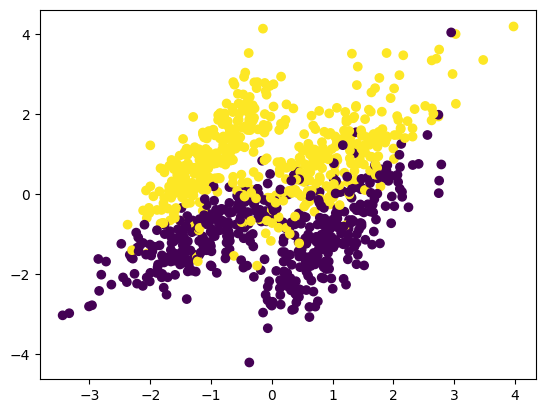

In [92]:
import matplotlib.pyplot as plt

plt.scatter(df['X'],df['Y'],c=df['target'])

In [93]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization, Dropout

**Without Normalization**

In [94]:
model = Sequential()

model.add(Dense(6,activation='relu',input_dim=2))
model.add(Dense(6,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [95]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [96]:
history = model.fit(X,Y,epochs=200,validation_split=0.2)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4913 - loss: 0.7198 - val_accuracy: 0.4700 - val_loss: 0.7288
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4913 - loss: 0.7079 - val_accuracy: 0.4500 - val_loss: 0.7207
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5075 - loss: 0.7020 - val_accuracy: 0.4600 - val_loss: 0.7139
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5175 - loss: 0.6974 - val_accuracy: 0.4500 - val_loss: 0.7108
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5200 - loss: 0.6947 - val_accuracy: 0.4600 - val_loss: 0.7085
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5275 - loss: 0.6934 - val_accuracy: 0.4750 - val_loss: 0.7062
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5288 - loss: 0.6923 - val_accuracy: 0.4900 - val_loss: 0.7043
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5312 - loss: 0.6914 - val_accuracy: 0.4850 - 

In [97]:
model1 = Sequential()

model1.add(Dense(6,activation='relu',input_dim=2))
model1.add(BatchNormalization()) # BatchNormalization Layer
model1.add(Dense(6,activation='relu'))
model1.add(BatchNormalization()) # BatchNormalization Layer
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 6)              │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 6)              │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 24 (96.00 B)

In [98]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [99]:
history1 = model.fit(X,Y, epochs=200, validation_split=0.2)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5587 - loss: 0.6847 - val_accuracy: 0.5100 - val_loss: 0.7023
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5587 - loss: 0.6847 - val_accuracy: 0.5150 - val_loss: 0.7027
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5575 - loss: 0.6846 - val_accuracy: 0.5100 - val_loss: 0.7028
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5612 - loss: 0.6846 - val_accuracy: 0.5150 - val_loss: 0.7024
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5600 - loss: 0.6847 - val_accuracy: 0.5100 - val_loss: 0.7020
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5587 - loss: 0.6846 - val_accuracy: 0.5100 - val_loss: 0.7030
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5612 - loss: 0.6846 - val_accuracy: 0.5100 - val_loss: 0.7026
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5600 - loss: 0.6845 - val_accuracy: 0.5150 - v

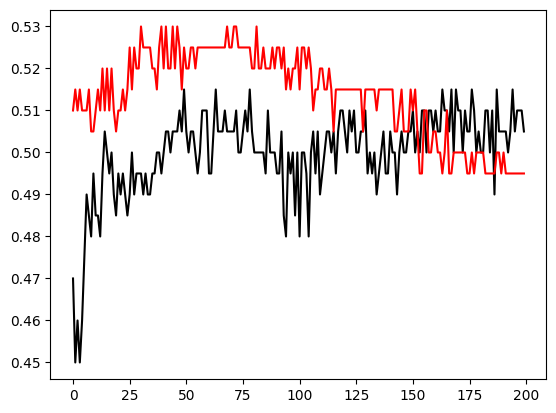

In [100]:
plt.plot(history.history['val_accuracy'], color='black')
plt.plot(history1.history['val_accuracy'], color='red')